In [ ]:
import itertools
import json
import math
import os
import random
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Sequence

import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Optional: mount Google Drive if your dataset/zip lives there
# from google.colab import drive
# drive.mount('/content/drive')

COLAB_DATA_ROOTS = [
    Path("/content/drive/MyDrive/crohme2019"),
    Path("/content/crohme2019"),
]
LOCAL_ZIP =  Path("/content/archive.zip")
LOCAL_DATA_ROOT = Path.cwd() / "dataset"
WORK_DIR = Path("/content/working") if Path("/content").exists() else Path.cwd() / ".local_work"

DATA_ROOT = None
for candidate in COLAB_DATA_ROOTS + [LOCAL_DATA_ROOT]:
    if (candidate / "crohme2019_train.txt").exists():
        DATA_ROOT = candidate
        break

if DATA_ROOT is None and LOCAL_ZIP.exists():
    DATA_ROOT = WORK_DIR / "crohme2019_dataset"
    if not (DATA_ROOT / "crohme2019_train.txt").exists():
        DATA_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(LOCAL_ZIP) as zf:
            zf.extractall(DATA_ROOT)

if DATA_ROOT is None:
    DATA_ROOT = COLAB_DATA_ROOTS[0]

WORK_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_ANNOTATION = DATA_ROOT / "crohme2019_train.txt"
VAL_ANNOTATION = DATA_ROOT / "crohme2019_valid.txt"
TEST_ANNOTATION = DATA_ROOT / "crohme2019_test.txt"

# Annotation rows contain relative paths such as crohme2019/test/example.inkml.
# Some dataset versions store those files under DATA_ROOT/crohme2019, while others
# store them under DATA_ROOT/crohme2019/crohme2019. Keep this path resolution in
# one place so the rest of the API remains stable.
INKML_ROOT = DATA_ROOT
if not (INKML_ROOT / "crohme2019" / "test").exists() and (DATA_ROOT / "crohme2019" / "crohme2019" / "test").exists():
    INKML_ROOT = DATA_ROOT / "crohme2019"

VOCAB_PATH = WORK_DIR / "vocab.json"

ANNOTATION_PATHS = [TRAIN_ANNOTATION, VAL_ANNOTATION, TEST_ANNOTATION]
RELATION_TOKENS = {"Above", "Below", "Inside", "NoRel", "Right", "Sub", "Sup"}

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"INKML_ROOT: {INKML_ROOT}")
print(f"WORK_DIR: {WORK_DIR}")

DATA_ROOT: /content/working/crohme2019_dataset
INKML_ROOT: /content/working/crohme2019_dataset/crohme2019
WORK_DIR: /content/working


##  Vocabulary

Labels are token sequences such as:

```text
- Right \sqrt Inside 2
```

A vocabulary maps each token to an integer class id. The blank token `""` is reserved for CTC and must be class `0`.

If `A` is the set of unique label tokens, the vocabulary is:

$$
V = \{\text{blank}\} \cup A
$$

with deterministic ordering:

$$
\text{char2idx}[t_i] = i, \quad [t_0, t_1, \dots] = \text{sorted}(V)
$$

Because `""` sorts first, it becomes index `0`.

<details><summary>Hint</summary>
Read each annotation file as tab-separated rows. The first column is the relative InkML path; the second column is the label string. Skip empty or missing labels, split labels by spaces, and collect tokens in a set. You can use numpy or pandas to handle tabular data.
</details>


In [2]:
def get_unique_tokens(annotation_paths: Sequence[str | Path]) -> set[str]:
    """Return all unique non-empty label tokens from annotation files.

    Args:
        annotation_paths: Paths to train/validation/test annotation files.

    Returns:
        A set of tokens found in non-empty labels.
    """
    tokens = set()
    for path in annotation_paths:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                tokens.update(parts[1:])
    tokens.discard("")
    return tokens


In [3]:
# Public check: unique token extraction
unique_tokens = get_unique_tokens(ANNOTATION_PATHS)

assert isinstance(unique_tokens, set)
assert "" not in unique_tokens
assert len(unique_tokens) == 108
for token in ["-", "Right", "\\sqrt", "Inside", "2", "\\pi", "\\exists", "|"]:
    assert token in unique_tokens

print("Unique token check passed.")


Unique token check passed.


In [4]:
class Vocab:
    """Vocabulary for CROHME label tokens.

    Attributes:
        char2idx: Mapping from token string to integer id.
        idx2char: Mapping from integer id to token string.
    """

    def __init__(self, vocab_file: str | Path | None = None):
        self.char2idx: dict[str, int] = {}
        self.idx2char: dict[int, str] = {}
        if vocab_file is not None:
            self.load(vocab_file)

    def _refresh_inverse(self) -> None:
        self.idx2char = {idx: token for token, idx in self.char2idx.items()}

    def build_vocab(self, annotation_paths: Sequence[str | Path]) -> None:
        """Build char2idx and idx2char from annotation files.

        The blank token "" must be included and must receive index 0.
        """
        tokens = sorted(get_unique_tokens(annotation_paths))
        self.char2idx = {"": 0} #V = {blank} U A
        for idx,token in enumerate(tokens, start=1):
            self.char2idx[token] = idx
        self._refresh_inverse()

    def save(self, path: str | Path) -> None:
        """Save char2idx as JSON."""
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with path.open("w", encoding="utf-8") as f:
            json.dump(self.char2idx, f, ensure_ascii=False, indent=2)

    def load(self, path: str | Path) -> None:
        """Load char2idx from JSON and rebuild idx2char."""
        with Path(path).open("r", encoding="utf-8") as f:
            data = json.load(f)
        self.char2idx = {str(token): int(idx) for token, idx in data.items()}
        self._refresh_inverse()

    def encode(self, tokens: Sequence[str]) -> list[int]:
        """Convert tokens to class ids."""
        result = []
        for token in tokens:
            result.append(self.char2idx[token])
        return result

    def decode(self, ids: Sequence[int]) -> list[str]:
        """Convert class ids back to tokens."""
        result = []
        for i in ids:
            result.append(self.idx2char[i])
        return result

In [5]:
# Public check: vocabulary
vocab = Vocab()
vocab.build_vocab(ANNOTATION_PATHS)
vocab.save(VOCAB_PATH)

loaded_vocab = Vocab(VOCAB_PATH)
example_tokens = "- Right \\sqrt Inside 2".split()

assert loaded_vocab.char2idx[""] == 0
assert len(loaded_vocab.char2idx) == 109
assert loaded_vocab.char2idx["-"] == 5
assert loaded_vocab.char2idx["2"] == 10
assert loaded_vocab.char2idx["Inside"] == 30
assert loaded_vocab.char2idx["Right"] == 37
assert loaded_vocab.char2idx["\\exists"] == 51
assert loaded_vocab.char2idx["\\pi"] == 68
assert loaded_vocab.char2idx["\\sqrt"] == 74
assert loaded_vocab.char2idx["|"] == 108
assert loaded_vocab.encode(example_tokens) == [5, 37, 74, 30, 10]
assert loaded_vocab.decode(loaded_vocab.encode(example_tokens)) == example_tokens

print("Vocabulary check passed.")


Vocabulary check passed.


## InkML Parser

`Inkml.getTraces()` returns a list of strokes. Each stroke is a sequence of points. Most files contain `(x, y)` points; some may include extra columns such as timestamps. Your feature code must use only the first two columns.

Do not redefine `Segment` or `Inkml` later in the notebook.


In [6]:
class Segment:
    """A labeled group of stroke ids from an InkML file."""

    __slots__ = ("id", "label", "strId")

    def __init__(self, *args):
        if len(args) == 3:
            self.id = args[0]
            self.label = args[1]
            self.strId = args[2]
        else:
            self.id = "none"
            self.label = ""
            self.strId = set()


class Inkml:
    """Parser for InkML stroke files."""

    __slots__ = ("fileName", "strokes", "strkOrder", "segments", "truth", "UI")

    NS = {
        "ns": "http://www.w3.org/2003/InkML",
        "xml": "http://www.w3.org/XML/1998/namespace",
    }

    def __init__(self, file_name: str | Path | None = None):
        self.fileName = None
        self.strokes: dict[str, str] = {}
        self.strkOrder: list[str] = []
        self.segments: dict[str, Segment] = {}
        self.truth = ""
        self.UI = ""
        if file_name is not None:
            self.fileName = str(file_name)
            self.loadFromFile()

    def fixNS(self, ns: str, att: str) -> str:
        return "{" + Inkml.NS[ns] + "}" + att

    def loadFromFile(self) -> None:
        tree = ET.parse(self.fileName)
        root = tree.getroot()

        for info in root.findall("ns:annotation", namespaces=Inkml.NS):
            if info.attrib.get("type") == "truth" and info.text:
                self.truth = info.text.strip()
            if info.attrib.get("type") == "UI" and info.text:
                self.UI = info.text.strip()

        for stroke in root.findall("ns:trace", namespaces=Inkml.NS):
            self.strokes[stroke.attrib["id"]] = stroke.text.strip()
            self.strkOrder.append(stroke.attrib["id"])

        segments = root.find("ns:traceGroup", namespaces=Inkml.NS)
        if segments is None or len(segments) == 0:
            return

        for seg in segments.iterfind("ns:traceGroup", namespaces=Inkml.NS):
            seg_id = seg.attrib[self.fixNS("xml", "id")]
            annotation = seg.find("ns:annotation", namespaces=Inkml.NS)
            label = annotation.text if annotation is not None else ""
            stroke_ids = {t.attrib["traceDataRef"] for t in seg.findall("ns:traceView", namespaces=Inkml.NS)}
            self.segments[seg_id] = Segment(seg_id, label, stroke_ids)

    def getTraces(self, height: int = 256) -> list[list[list[float]]]:
        traces = []
        for stroke_id in self.strkOrder:
            points = [p.strip().split() for p in self.strokes[stroke_id].split(",") if p.strip()]
            traces.append(np.array(points, dtype=float))

        all_xy = np.concatenate([trace[:, :2] for trace in traces], axis=0)
        y_span = all_xy[:, 1].max() - all_xy[:, 1].min()
        ratio = height / (y_span + 1e-6)

        scaled = []
        for trace in traces:
            trace = trace.copy()
            trace[:, :2] *= ratio
            scaled.append(trace.astype(int).tolist())
        return scaled

    def view(self) -> None:
        plt.figure(figsize=(16, 4))
        plt.axis("off")
        for trace in self.getTraces():
            arr = np.asarray(trace, dtype=np.float32)
            plt.plot(arr[:, 0], -arr[:, 1])
        plt.show()


In [7]:
# Probe cell: inspect one InkML file.
sample_ink = Inkml(INKML_ROOT / "crohme2019" / "test" / "UN19_1041_em_597.inkml")
print(sample_ink.truth)
print([np.asarray(trace).shape for trace in sample_ink.getTraces()[:5]])


$-\sqrt2$
[(27, 2), (144, 2), (135, 2)]


## Feature Extraction

For consecutive points $(x_i, y_i)$ and $(x_{i+1}, y_{i+1})$:

$$
\Delta x_i = x_{i+1} - x_i, \quad \Delta y_i = y_{i+1} - y_i
$$

$$
d_i = \sqrt{\Delta x_i^2 + \Delta y_i^2}
$$

The feature at timestep `i` is:

$$
\mathbf{x}_i = \left[\frac{\Delta x_i}{d_i}, \frac{\Delta y_i}{d_i}, d_i, pen\_up_i\right]
$$

`pen_up_i = 1` only when the transition crosses from the end of one stroke to the start of the next stroke; otherwise it is `0`.

<details><summary>Hint</summary>
Concatenate strokes first, compute differences once, then mark pen-up transitions using cumulative stroke lengths. Remove rows where `d_i == 0` before normalizing to avoid division by zero. Return `np.float32`.
</details>


In [8]:
def feature_extraction(traces: Sequence[Sequence[Sequence[float]]]) -> np.ndarray:
    """Convert InkML traces into `(dx/d, dy/d, d, pen_up)` features.

    Args:
        traces: List of strokes. Each stroke is a sequence of points. Only x/y
            columns should be used.

    Returns:
        A float32 NumPy array of shape `(T, 4)`.
    """
    strokes = np.concatenate([np.asarray(trace, dtype=np.float32)[:, :2] for trace in traces],axis=0)

    stroke_ends = np.cumsum([len(trace) for trace in traces])[:-1]
    res = []
    for i in range(len(strokes)-1):
        pen_up = 1.0 if i == len(strokes) - 2 else 0.0
        dx = strokes[i+1][0] - strokes[i][0]
        dy = strokes[i+1][1] - strokes[i][1]
        di = np.sqrt(dx*dx + dy*dy)
        if di == 0:
            continue
        res.append([dx/di, dy/di, di, pen_up])

    return np.array(res, dtype=np.float32)


In [9]:
# Public check: feature extraction
valid_ink = Inkml(INKML_ROOT / "crohme2019" / "valid" / "18_em_0.inkml")
features_np = feature_extraction(valid_ink.getTraces())
print(features_np.shape)
assert isinstance(features_np, np.ndarray)
assert features_np.dtype == np.float32
assert features_np.shape == (614, 4)
np.testing.assert_allclose(features_np[:, :3].mean(axis=0), np.array([0.17677799, 0.29519369, 11.35540311]), rtol=1e-5)
np.testing.assert_allclose(features_np[:, :3].var(axis=0), np.array([3.75390418e-01, 5.06219812e-01, 4.19017361e+02]), rtol=1e-5)
assert set(np.unique(features_np[:, 3])).issubset({0.0, 1.0})

print("Feature extraction check passed.")


(614, 4)
Feature extraction check passed.


## Visualizations Helper

Static plots are useful for catching mistakes before training. Implement these helpers so you can inspect raw strokes, extracted feature channels, and model emission probabilities.


In [10]:
def plot_inkml(ink: Inkml, title: str | None = None) -> plt.Figure:
    """Plot all strokes from one InkML object and return the Matplotlib figure."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis("off")
    for trace in ink.getTraces():
        arr = np.asarray(trace, dtype=float)
        if arr.ndim == 2 and arr.shape[0] > 0:
            ax.plot(arr[:, 0], -arr[:, 1], linewidth=1.5)
    ax.set_title(title or ink.truth or Path(str(ink.fileName)).name)
    fig.tight_layout()
    return fig


def plot_feature_channels(features: np.ndarray | torch.Tensor, title: str | None = None) -> plt.Figure:
    """Plot the four feature channels `(dx/d, dy/d, d, pen_up)` over time."""
    if torch.is_tensor(features):
        features_np = features.detach().cpu().numpy()
    else:
        features_np = np.asarray(features)

    names = ["dx / d", "dy / d", "distance", "pen_up"]
    fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
    for channel, ax in enumerate(axes):
        ax.plot(features_np[:, channel], linewidth=1.0)
        ax.set_ylabel(names[channel])
        ax.grid(alpha=0.25)
    axes[-1].set_xlabel("Timestep")
    fig.suptitle(title or "Extracted feature channels")
    fig.tight_layout()
    return fig

def plot_prediction_probs(emission: torch.Tensor, vocab: Vocab, threshold: float = 0.2, title: str | None = None):
    y_prob = emission.exp().numpy()
    col_ids = np.where(y_prob.max(0) > threshold)[0]
    data = y_prob[:, col_ids]
    columns = [list(vocab.char2idx.keys())[id] for id in col_ids]

    df_pred = pd.DataFrame(data, columns=columns)
    df_pred.rename(columns={'': '<blank>'}, inplace=True)

    fig = px.line(df_pred, title=title)
    fig.update_traces(mode='lines')
    for trace in fig.data:
        if trace.name == '<blank>':
            trace.update(line=dict(dash='dash', width=0.5))
    return fig


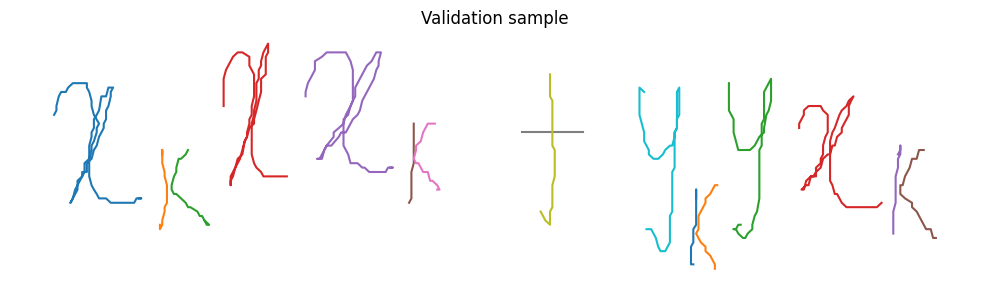

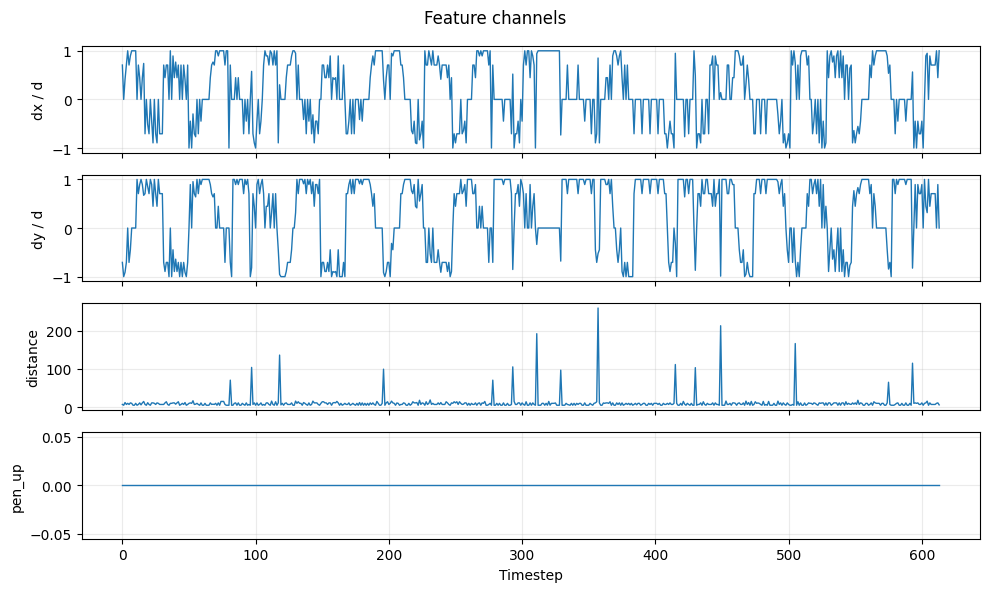

In [ ]:
# Ink and feature visualization
fig_ink = plot_inkml(valid_ink, title="Validation sample")
fig_features = plot_feature_channels(features_np, title="Feature channels")

In [ ]:
# Synthetic emission visualization
random_emission = torch.log_softmax(torch.randn(20, len(loaded_vocab.char2idx)), dim=-1)
plot_prediction_probs(random_emission, loaded_vocab, threshold=0.1, title="Synthetic emission")


## Dataset

Each annotation row maps an InkML file to a target token sequence.

Your dataset item must return:

```python
features: Tensor[T, 4]      # float32
targets: Tensor[U]          # long
input_len: int              # T
target_len: int             # U
```

These lengths are required by `nn.CTCLoss`.

<details><summary>Hint</summary>
Read the annotation file in `__init__`, skip empty labels, and store `(inkml_path, label_tokens)` pairs. In `__getitem__`, parse the file with `Inkml`, call `feature_extraction`, encode target tokens with `vocab.encode`, and convert both arrays to tensors.
</details>


In [11]:
class InkmlDataset(Dataset):
    """CROHME InkML dataset for CTC training."""

    def __init__(self, annotation: str | Path, root_dir: str | Path, vocab: Vocab):
        self.annotation = Path(annotation)
        self.root_dir = Path(root_dir)
        self.vocab = vocab
        self.samples: list[tuple[str, list[str]]] = []

        with open(self.annotation, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                parts = line.split()
                inkml_path = parts[0]
                label_tokens = parts[1:]
                if len(label_tokens) == 0:
                    continue

                self.samples.append((inkml_path, label_tokens))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, int, int]:
        inkml_path, label_tokens = self.samples[idx]
        ink = Inkml(self.root_dir / inkml_path)
        features = feature_extraction(ink.getTraces())
        target_ids = self.vocab.encode(label_tokens)
        features = torch.tensor(features, dtype=torch.float32)
        targets = torch.tensor(target_ids, dtype=torch.long)

        return (features, targets, features.size(0), targets.size(0))


In [12]:
# Public check: dataset item
dataset = InkmlDataset(TEST_ANNOTATION, INKML_ROOT, loaded_vocab)
features, targets, input_len, target_len = dataset[0]

assert len(dataset) > 0
assert isinstance(features, torch.Tensor) and features.dtype == torch.float32
assert isinstance(targets, torch.Tensor) and targets.dtype == torch.long
assert features.ndim == 2 and features.shape[1] == 4
assert targets.ndim == 1
assert input_len == features.shape[0]
assert target_len == targets.shape[0]
assert input_len > target_len > 0

print("Dataset check passed.")


Dataset check passed.


## Collate Function and DataLoaders

Samples have different input and target lengths. A batch therefore needs padding.

The collate function must return:

```python
features: Tensor[B, Tmax, 4]
targets: Tensor[B, Umax]
input_lens: Tensor[B]       # long
target_lens: Tensor[B]      # long
```

Then build plain PyTorch `DataLoader` objects for train, validation, and test. Do not use a Lightning `DataModule` in this assignment.

<details><summary>Hint</summary>
Use `zip(*batch)` to unpack samples and `pad_sequence(..., batch_first=True)` for both features and targets. Convert the lengths to `torch.long` tensors. The training loader should shuffle; validation and test loaders should not. In notebooks, start with `num_workers=0`; multiprocessing workers can raise `BrokenPipeError` when dataset classes/functions are defined inside notebook cells.
</details>


In [13]:
def collate_fn(batch: Sequence[tuple[torch.Tensor, torch.Tensor, int, int]]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Pad a batch of variable-length CTC samples."""
    features, targets, input_lens, target_lens = zip(*batch)
    features = pad_sequence(features, batch_first=True)
    targets = pad_sequence(targets, batch_first=True)
    input_lens = torch.tensor(input_lens, dtype=torch.long)
    target_lens = torch.tensor(target_lens, dtype=torch.long)

    return features, targets, input_lens, target_lens



In [14]:
def create_dataloaders(
    train_annotation: str | Path,
    val_annotation: str | Path,
    test_annotation: str | Path,
    root_dir: str | Path,
    vocab: Vocab,
    batch_size: int = 32,
    num_workers: int = 0,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Create train/validation/test DataLoaders using the canonical dataset and collate function."""
    train = InkmlDataset(train_annotation, root_dir, vocab)
    val = InkmlDataset(val_annotation, root_dir, vocab)
    test = InkmlDataset(test_annotation, root_dir, vocab)

    train_dloader = DataLoader(
        train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=collate_fn
    )

    val_dloader = DataLoader(
        val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    test_dloader = DataLoader(
        test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )

    return train_dloader, val_dloader, test_dloader


In [15]:
# Public check: collate function
batch = [dataset[0], dataset[1]]
batch_features, batch_targets, input_lens, target_lens = collate_fn(batch)

assert batch_features.ndim == 3 and batch_features.shape[0] == 2 and batch_features.shape[2] == 4
assert batch_targets.ndim == 2 and batch_targets.shape[0] == 2
assert input_lens.dtype == torch.long and target_lens.dtype == torch.long
assert input_lens.tolist() == [batch[0][2], batch[1][2]]
assert target_lens.tolist() == [batch[0][3], batch[1][3]]

print("Collate check passed.")


Collate check passed.


In [16]:
# Public check: dataloader setup and one batch
train_dataloader, val_dataloader, test_dataloader = create_dataloaders(
    TRAIN_ANNOTATION,
    VAL_ANNOTATION,
    TEST_ANNOTATION,
    INKML_ROOT,
    loaded_vocab,
    batch_size=4,
    num_workers=0,
)
one_batch = next(iter(train_dataloader))

assert len(one_batch) == 4
assert one_batch[0].ndim == 3 and one_batch[0].shape[-1] == 4
assert one_batch[1].ndim == 2
assert one_batch[2].dtype == torch.long and one_batch[3].dtype == torch.long

print("DataLoader check passed.")


DataLoader check passed.


## Model and CTC Loss

The model consumes feature sequences and predicts a log-probability distribution over vocabulary classes at every timestep.

| Layer | Configuration |
|---|---|
| Input | `(B, T, 4)` |
| LSTM | `hidden_size=256`, `num_layers=2`, `batch_first=True`, `bidirectional=True` |
| Linear | `hidden_size * 2 -> num_classes` |
| Activation | `LogSoftmax(dim=-1)` |
| Output | `(B, T, num_classes)` |

CTC marginalizes over alignments. For target sequence `y` and input `x`:

$$
L_{CTC}(x, y) = -\log \sum_{\pi \in \mathcal{B}^{-1}(y)} \prod_{t=1}^{T} p(\pi_t \mid x)
$$

PyTorch `nn.CTCLoss` expects model outputs as `(T, B, C)`, so you must permute `(B, T, C)` before computing loss.

<details><summary>Hint</summary>
For a bidirectional LSTM, the output hidden dimension is `hidden_size * 2`. Apply `nn.LogSoftmax(dim=-1)` after the linear layer so the output is ready for `nn.CTCLoss`.
</details>


In [17]:
class LSTMTemporalClassifier(nn.Module):
    """Bidirectional LSTM temporal classifier for CTC."""

    def __init__(self, input_size: int = 4, hidden_size: int = 256, num_layers: int = 2, num_classes: int = 109):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=hidden_size,
            num_layers=2, batch_first=True,
            bidirectional=True)
        self.linear = nn.Linear(hidden_size * 2, num_classes)
        self.activation = nn.LogSoftmax(dim=-1)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return log-probabilities with shape `(B, T, C)`."""
        x, _ = self.lstm(x)          # (B, T, 512)
        x = self.linear(x)              # (B, T, C)
        x = self.activation(x)     # (B, T, C)

        return x



In [18]:
# Public check: model output shape and log-probabilities
model = LSTMTemporalClassifier(input_size=4, hidden_size=16, num_layers=1, num_classes=len(loaded_vocab.char2idx))
x = torch.randn(3, 25, 4)
y_hat = model(x)

assert y_hat.shape == (3, 25, len(loaded_vocab.char2idx))
assert torch.allclose(y_hat.exp().sum(dim=-1), torch.ones(3, 25), atol=1e-5)

print("Model check passed.")


Model check passed.


## Greedy Decoder and Metrics

For each timestep, greedy decoding chooses:

$$
\hat{c}_t = \arg\max_c \log p(c \mid x_t)
$$

Then CTC post-processing is:

```text
argmax ids -> collapse consecutive repeats -> remove blank -> tokens
```

Word error rate is token-level edit distance normalized by target length:

$$
WER = \frac{\sum_i ED(\hat{y}_i, y_i)}{\sum_i |y_i|}
$$

<details><summary>Hint</summary>
The decoder should accept either one emission `(T, C)` or a batch `(B, T, C)`. Use `vocab.char2idx[""]` for the blank id and `vocab.idx2char` for decoding ids.
</details>


In [19]:
class GreedyCTCDecoder(nn.Module):
    """Greedy CTC decoder using the canonical Vocab interface."""

    def __init__(self, vocab: Vocab):
        super().__init__()
        self.vocab = vocab
        self.blank = vocab.char2idx[""]

    def decode(self, em: torch.Tensor) -> str:
        #arg max id
        indices = em.argmax(dim=-1)
        # collapse repeats
        previous = indices[0]
        collapsed = [previous]
        for idx in indices[1:]:
            if idx != previous:
                collapsed.append(idx)
                previous = idx
        #remove blanks
        chars = [self.vocab.idx2char[i.item()] for i in collapsed if i != self.blank]
        return chars

    def forward(self, emission: torch.Tensor) -> list[str] | list[list[str]]:
        """Decode one emission `(T, C)` or a batch `(B, T, C)`."""
        if emission.dim() == 2:  # single
            return self.decode(emission)
        elif emission.dim() == 3:  # batch
            return [self.decode(em) for em in emission]

In [20]:
# Public check: greedy decoder on synthetic emissions
toy_vocab = Vocab()
toy_vocab.char2idx = {"": 0, "a": 1, "b": 2}
toy_vocab._refresh_inverse()

decoder = GreedyCTCDecoder(toy_vocab)
emission = torch.tensor([
    [0.0, 5.0, 0.0],  # a
    [0.0, 4.0, 0.0],  # repeated a -> collapse
    [5.0, 0.0, 0.0],  # blank -> remove
    [0.0, 0.0, 5.0],  # b
])

assert decoder(emission) == ["a", "b"]
assert decoder(emission.unsqueeze(0)) == [["a", "b"]]

print("Decoder check passed.")


Decoder check passed.


In [21]:
def edit_distance(pred_seq: Sequence[str], label_seq: Sequence[str]) -> int:
    """Token-level Levenshtein edit distance."""
    m, n = len(pred_seq), len(label_seq)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i  # i deletions
    for j in range(n + 1):
        dp[0][j] = j  # j insertions

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if pred_seq[i - 1] == label_seq[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j],     # deletion
                    dp[i][j - 1],     # insertion
                    dp[i - 1][j - 1]  # substitution
                )

    return dp[m][n]


def word_error_rate(preds: Sequence[Sequence[str]], targets: Sequence[Sequence[str]]) -> float:
    """Compute sum edit distance divided by sum target token lengths."""
    total_edits = 0
    total_tokens = 0
    for pred_seq, label_seq in zip(preds, targets):
        total_edits += edit_distance(pred_seq, label_seq)
        total_tokens += len(label_seq)
    return total_edits / total_tokens


In [22]:
# Public check: metrics
pred = ["\\phi", "Right", "(", "Right", "0", "Right", ")"]
target = ["\\phi", "Right", "(", "Right", "n", "Right", ")"]

assert edit_distance(pred, target) == 1
assert edit_distance(["a", "b"], ["a", "x", "b"]) == 1
assert math.isclose(word_error_rate([pred, ["a"]], [target, ["a", "b"]]), 2 / 9)

print("Metric check passed.")


Metric check passed.


## CTC Training Utilities

Build the reusable training/evaluation helpers yourself with plain PyTorch:

- move each batch to the selected device,
- compute `nn.CTCLoss` from `(B, T, C)` model log-probabilities,
- run `optimizer.zero_grad()`, `loss.backward()`, and `optimizer.step()` inside one epoch,
- use the provided tqdm helpers for batch progress,
- evaluate without gradients,
- decode validation/test outputs and compute WER.

The full multi-epoch training loop with WandB logging, checkpointing, and early stopping is in Task 8.

<details><summary>Hint</summary>
For CTC loss, call `criterion(log_probs.permute(1, 0, 2), targets, input_lens, target_lens)`. Length tensors and targets must be on the same device expected by your PyTorch version. Use `model.train()` for training and `model.eval()` with `torch.no_grad()` for evaluation. The helpers `progress_batches` and `log_progress` already wrap `tqdm`, handle `max_batches`, and update the progress-bar postfix for you.
</details>


**Interpreting `val_wer = 1.0`:** this usually means the current CTC model is decoding an empty token sequence for most or all validation samples. For an empty prediction, edit distance equals the full target length, so corpus WER becomes exactly `1.0`. This is common during smoke runs or very early CTC training because the blank class is an easy alignment. Watch `val_empty_pred_rate`, `val_avg_pred_len`, and `val_avg_target_len` to confirm this. For real training, set the debug batch limits to `None` and train on the full split.


In [23]:
def format_progress_value(value):
    """Format values for tqdm postfix display."""
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.4f}"
    if torch.is_tensor(value):
        return f"{float(value.detach().cpu()):.4f}" if value.numel() == 1 else str(tuple(value.shape))
    return value


def log_progress(progress, **metrics) -> None:
    """Update a tqdm progress bar with compact metric values."""
    progress.set_postfix({key: format_progress_value(value) for key, value in metrics.items()})


def progress_batches(dataloader, desc: str, max_batches: int | None = None, leave: bool = False):
    """Yield `(batch_idx, batch, progress)` from a dataloader with a tqdm bar.

    The `max_batches` argument is handled here so training/evaluation loops stay focused
    on model logic instead of progress-bar bookkeeping.
    """
    if max_batches is None:
        iterable = dataloader
        total = len(dataloader) if hasattr(dataloader, "__len__") else None
    else:
        iterable = itertools.islice(dataloader, max_batches)
        total = min(len(dataloader), max_batches) if hasattr(dataloader, "__len__") else max_batches

    progress = tqdm(iterable, desc=desc, total=total, leave=leave)
    for batch_idx, batch in enumerate(progress):
        yield batch_idx, batch, progress


def progress_epochs(num_epochs: int):
    """Return a tqdm bar over epoch numbers starting at 1."""
    return tqdm(range(1, int(num_epochs) + 1), desc="epochs")


def compute_ctc_loss(
    model: nn.Module,
    criterion: nn.CTCLoss,
    batch: tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor],
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return `(loss, log_probs)` for one CTC batch."""
    # TODO: unpack the batch into features, targets, input_lens, and target_lens.
    # TODO: move tensors to `device`.
    # TODO: run the model to obtain log_probs with shape (B, T, C).
    # TODO: compute CTC loss. Remember CTCLoss expects log_probs as (T, B, C).
    # TODO: return both the scalar loss and the unpermuted log_probs for decoding.
    features, targets, input_lens, target_lens = batch
    features = features.to(device)
    targets = targets.to(device)
    input_lens = input_lens.to(device)
    target_lens = target_lens.to(device)

    log_probs = model(features)
    ctc_loss = criterion(log_probs.permute(1, 0, 2), targets, input_lens, target_lens)

    return ctc_loss, log_probs



def decode_batch(
    log_probs: torch.Tensor,
    targets: torch.Tensor,
    input_lens: torch.Tensor,
    target_lens: torch.Tensor,
    decoder: GreedyCTCDecoder,
    vocab: Vocab,
) -> tuple[list[list[str]], list[list[str]]]:
    """Decode model outputs and target ids for one batch."""
    # TODO: for each sample, slice log_probs to its real input length before decoding.
    # TODO: for each sample, slice targets to its real target length before vocab.decode(...).
    # TODO: return two lists: predicted token sequences and target token sequences.
    predict: list[list[str]] = []
    target: list[list[str]] = []

    for i in range(log_probs.size(0)):
        real_log_probs = log_probs[i, :input_lens[i], :] #size, sequence len (trim this), classes
        real_targets = targets[i, :target_lens[i]] #size, sequence len (trim this also)

        pred_seq = decoder(real_log_probs)
        target_seq = vocab.decode(real_targets.tolist())

        predict.append(pred_seq)
        target.append(target_seq)

    return predict, target


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.CTCLoss,
    device: torch.device,
    grad_clip_norm: float | None = None,
    max_batches: int | None = None,
) -> float:
    """Run one manual training epoch and return mean loss."""
    # TODO: switch the model to training mode.
    # TODO: iterate with `for batch_idx, batch, progress in progress_batches(dataloader, "train", max_batches):`.
    # TODO: compute loss with compute_ctc_loss(...).
    # TODO: zero gradients, backpropagate, optionally clip gradients, and step optimizer.
    # TODO: accumulate a batch-size-weighted average loss.
    # TODO: call `log_progress(progress, loss=loss, mean_loss=mean_loss)` inside the loop.
    # TODO: return the mean training loss.
    model.train()
    total_loss = 0.0
    total_samples = 0
    for batch_idx, batch, progress in progress_batches(dataloader, "train", max_batches):
        loss, log_probs = compute_ctc_loss(model, criterion, batch, device)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        batch_size = batch[0].size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        mean_loss = total_loss / total_samples

        log_progress(progress, loss=loss.item(), mean_loss=mean_loss)

    return mean_loss


def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.CTCLoss,
    decoder: GreedyCTCDecoder,
    vocab: Vocab,
    device: torch.device,
    max_batches: int | None = None,
) -> dict[str, float]:
    """Run manual evaluation and return at least `loss` and `wer`."""
    # TODO: switch the model to evaluation mode.
    # TODO: wrap the loop in torch.no_grad().
    # TODO: iterate with `progress_batches(dataloader, "eval", max_batches)`.
    # TODO: compute validation/test loss for each batch.
    # TODO: decode predictions and targets, then compute WER across the whole split.
    # TODO: call `log_progress(progress, loss=mean_loss)` inside the loop.
    # TODO: also report diagnostics such as empty prediction rate and average lengths.
    #       If WER is exactly 1.0, these diagnostics usually show that predictions are empty.
    # TODO: return a dictionary such as:
    #       {"loss": ..., "wer": ..., "empty_pred_rate": ..., "avg_pred_len": ..., "avg_target_len": ...}
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_preds: list[list[str]] = []
    all_target: list[list[str]] = []

    with torch.no_grad():
        for batch_idx, batch, progress in progress_batches(dataloader, "eval", max_batches):
            loss, log_probs = compute_ctc_loss(model, criterion, batch, device)

            features, targets, input_lens, target_lens = batch
            batch_size = targets.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size
            mean_loss = total_loss / total_samples

            preds, target = decode_batch(log_probs, targets, input_lens, target_lens, decoder, vocab)
            all_preds.extend(preds)
            all_target.extend(target)

            log_progress(progress, loss=mean_loss)

    wer = word_error_rate(all_preds, all_target)

    empty_pred_count = sum(1 for p in all_preds if len(p) == 0)
    empty_pred_rate = empty_pred_count / len(all_preds) if all_preds else 0.0

    avg_pred_len = sum(len(p) for p in all_preds) / len(all_preds) if all_preds else 0.0
    avg_target_len = sum(len(r) for r in all_target) / len(all_target) if all_target else 0.0

    return {
        "loss": mean_loss,
        "wer": wer,
        "empty_pred_rate": empty_pred_rate,
        "avg_pred_len": avg_pred_len,
        "avg_target_len": avg_target_len,
    }


In [24]:
# Public check: finite manual CTC step on a tiny artificial batch
small_vocab = Vocab()
small_vocab.char2idx = {"": 0, "a": 1, "b": 2}
small_vocab._refresh_inverse()

small_model = LSTMTemporalClassifier(input_size=4, hidden_size=8, num_layers=1, num_classes=3)
small_criterion = nn.CTCLoss(blank=small_vocab.char2idx[""], zero_infinity=True)
small_optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)
small_batch = (
    torch.randn(2, 12, 4),
    torch.tensor([[1, 2], [1, 0]], dtype=torch.long),
    torch.tensor([12, 12], dtype=torch.long),
    torch.tensor([2, 1], dtype=torch.long),
)
small_device = torch.device("cpu")
loss, small_log_probs = compute_ctc_loss(small_model, small_criterion, small_batch, small_device)
assert torch.is_tensor(loss)
assert torch.isfinite(loss)
loss.backward()
small_optimizer.zero_grad(set_to_none=True)

train_loss = train_one_epoch(small_model, [small_batch], small_optimizer, small_criterion, small_device)
small_decoder = GreedyCTCDecoder(small_vocab)
metrics = evaluate_model(small_model, [small_batch], small_criterion, small_decoder, small_vocab, small_device)

assert math.isfinite(train_loss)
assert set(metrics) >= {"loss", "wer"}
assert math.isfinite(metrics["loss"])

print("Manual CTC training utility check passed.")


train:   0%|          | 0/1 [00:00<?, ?it/s]

eval:   0%|          | 0/1 [00:00<?, ?it/s]

Manual CTC training utility check passed.


## Task 8: Mandatory WandB Manual Training

Your submission must log to WandB using the fixed course entity and project. In Kaggle, add your key as a secret or environment variable named `WANDB_API_KEY`.

You must set the `STUDENT_ID` constant in the next cell before training. This value is used in the WandB run name and config so your submission can be matched to your account for grading. Leaving `STUDENT_ID = "YOUR_STUDENT_ID"` will intentionally stop the notebook.

The helper below uses `reinit="create_new"` so rerunning notebook cells does not try to finish a stale WandB run. If online WandB initialization fails because of a transient local connection/service issue, it falls back to offline logging for debugging. For final submission, make sure you have a real online WandB run under the course entity/project.

Model quality is not graded by a hard `val_loss < 0.7` threshold. Correct implementation, reproducibility, manual training-loop code, early stopping, checkpoints, visual inspection, and WandB logs are the base grading target.


In [ ]:
# REQUIRED: replace this constant with your own student ID before running training.
# Example format: STUDENT_ID = "10422021"
STUDENT_ID = "104240134"

if STUDENT_ID == "YOUR_STUDENT_ID" or not STUDENT_ID.strip():
    raise ValueError(
        "Set the STUDENT_ID constant at the top of this cell before training. "
        "This ID is required for WandB logging and grading."
    )


class NoOpWandbRun:
    """Fallback object so local debugging can continue if WandB cannot start."""

    class Config(dict):
        def update(self, *args, **kwargs):
            kwargs.pop("allow_val_change", None)
            return super().update(*args, **kwargs)

    def __init__(self, config: dict | None = None):
        self.config = self.Config(config or {})

    def log(self, metrics: dict) -> None:
        print(f"[wandb disabled] {metrics}")

    def finish(self) -> None:
        pass


def init_wandb_run(
    student_id: str,
    api_key: str,
    config: dict,
    allow_offline_fallback: bool = True,
):
    """Initialize WandB robustly for notebook reruns."""
    if student_id == "YOUR_STUDENT_ID" or not student_id.strip():
        raise ValueError("Set the STUDENT_ID constant before training.")
    if not api_key:
        raise ValueError("Set WANDB_API_KEY in Kaggle secrets or environment variables before training.")

    wandb.login(key=api_key)
    init_kwargs = {
        "entity": "cuong-nt-vgu-ai-2026",
        "project": "math_online_2026",
        "name": f"{student_id}_crohme_ctc",
        "config": config,
        "reinit": "create_new",
    }

    try:
        return wandb.init(**init_kwargs)
    except Exception as exc:
        if not allow_offline_fallback:
            raise
        print(f"WandB online init failed ({type(exc).__name__}: {exc}). Retrying in offline mode for debugging.")
        try:
            os.environ["WANDB_MODE"] = "offline"
            return wandb.init(**init_kwargs, mode="offline")
        except Exception as offline_exc:
            print(f"WandB offline init also failed ({type(offline_exc).__name__}: {offline_exc}). Using a no-op logger.")
            return NoOpWandbRun(config)


api_key = os.environ.get("WANDB_API_KEY", "")

if not api_key:
    try:
        from kaggle_secrets import UserSecretsClient

        api_key = UserSecretsClient().get_secret("WANDB_API_KEY")
    except Exception:
        api_key = ""

wandb_run = init_wandb_run(
    student_id=STUDENT_ID,
    api_key=api_key,
    config={
        "student_id": STUDENT_ID,
        "model": "LSTMTemporalClassifier",
        "seed": SEED,
    },
)

print(f"WandB run configured for student_id={STUDENT_ID}.")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning:

invalid escape sequence '\/'

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 104240134 (104240134-vietnamese-german-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB run configured for student_id=104240134.


In [ ]:
# Public check: one-batch manual smoke run. This checks the loop mechanics, not final quality.
smoke_train_loader, smoke_val_loader, _ = create_dataloaders(
    TRAIN_ANNOTATION,
    VAL_ANNOTATION,
    TEST_ANNOTATION,
    INKML_ROOT,
    loaded_vocab,
    batch_size=2,
    num_workers=0,
)
smoke_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
smoke_model = LSTMTemporalClassifier(
    input_size=4,
    hidden_size=16,
    num_layers=1,
    num_classes=len(loaded_vocab.char2idx),
).to(smoke_device)
smoke_optimizer = torch.optim.Adam(smoke_model.parameters(), lr=1e-3)
smoke_criterion = nn.CTCLoss(blank=loaded_vocab.char2idx[""], zero_infinity=True)
smoke_decoder = GreedyCTCDecoder(loaded_vocab)

smoke_train_loss = train_one_epoch(smoke_model, smoke_train_loader, smoke_optimizer, smoke_criterion, smoke_device, max_batches=1)
smoke_val_metrics = evaluate_model(smoke_model, smoke_val_loader, smoke_criterion, smoke_decoder, loaded_vocab, smoke_device, max_batches=1)

assert math.isfinite(smoke_train_loss)
assert math.isfinite(smoke_val_metrics["loss"])
print("Manual one-batch smoke check passed.")


train:   0%|          | 0/1 [00:00<?, ?it/s]

eval:   0%|          | 0/1 [00:00<?, ?it/s]

Manual one-batch smoke check passed.


In [ ]:
# Full training run skeleton. Fill in the setup and call your manual training loop.
# Keep `max_train_batches` and `max_val_batches` small while debugging; set them to None for real training.

config = {
    "lr": 1e-3,
    "batch_size": 32,
    "seed": SEED,
    "num_epochs": 20,
    "input_size": 4,
    "hidden_size": 256,
    "num_layers": 2,
    "num_classes": len(loaded_vocab.char2idx),
    "patience": 5,
    "min_delta": 1e-4,
    "grad_clip_norm": 5.0,
    "max_train_batches": None,
    "max_val_batches": None,
}

# TODO: implement the multi-epoch training loop below. This is the command-level
# training function that should call train_one_epoch(...) and evaluate_model(...).
def fit_with_early_stopping(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.CTCLoss,
    decoder: GreedyCTCDecoder,
    vocab: Vocab,
    device: torch.device,
    config: dict,
    run=None,
    checkpoint_dir: str | Path | None = None,
) -> tuple[list[dict[str, float]], Path | None]:
    """Train manually with WandB logging, checkpointing, and early stopping."""
    # TODO: create the checkpoint directory.
    # TODO: initialize best validation loss, best checkpoint path, patience counter, and history.
    # TODO: loop with `for epoch in progress_epochs(config["num_epochs"]):`.
    # TODO: for each epoch:
    #       1. call train_one_epoch(...)
    #       2. call evaluate_model(...) on the validation loader
    #       3. log train_loss, val_loss, val_wer, val_empty_pred_rate, and epoch to WandB when `run` is not None
    #       4. call `log_progress(epoch_bar, train_loss=..., val_loss=..., val_wer=..., empty=...)`
    #       5. save a checkpoint when validation loss improves
    #       6. stop when validation loss has not improved for `config["patience"]` epochs
    # TODO: return the history list and the best checkpoint path.
    checkpoint_dir = Path(checkpoint_dir) if checkpoint_dir is not None else Path("checkpoints")
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    best_val_loss = float("inf")
    best_checkpoint_path: Path | None = None
    patience_counter = 0
    history: list[dict[str, float]] = []

    epoch_bar = progress_epochs(config["num_epochs"])
    for epoch in epoch_bar:
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            max_batches=config["max_train_batches"],
            grad_clip_norm=config["grad_clip_norm"],
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            decoder,
            vocab,
            device,
            max_batches=config["max_val_batches"],
        )
        val_loss = val_metrics["loss"]
        val_wer = val_metrics["wer"]
        val_empty_pred_rate = val_metrics["empty_pred_rate"]

        if run is not None:
            run.log(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_wer": val_wer,
                    "val_empty_pred_rate": val_empty_pred_rate,
                    "epoch": epoch,
                }
            )

        log_progress(
            epoch_bar,
            train_loss=train_loss,
            val_loss=val_loss,
            val_wer=val_wer,
            empty=val_empty_pred_rate,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_wer": val_wer,
                "val_empty_pred_rate": val_empty_pred_rate,
            }
        )

        if val_loss < best_val_loss - config["min_delta"]:
            best_val_loss = val_loss
            patience_counter = 0
            best_checkpoint_path = checkpoint_dir / f"best_model_epoch{epoch}.pt"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                    "config": config,
                },
                best_checkpoint_path,
            )
        else:
            patience_counter += 1
            if patience_counter >= config["patience"]:
                break

    return history, best_checkpoint_path


# TODO: update the WandB run config with the training hyperparameters.
# TODO: choose `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")`.
# TODO: create train/validation/test dataloaders with create_dataloaders(...). Use num_workers=0 in notebooks first.
# TODO: instantiate LSTMTemporalClassifier and move it to the device.
# TODO: create the Adam optimizer, CTCLoss, and GreedyCTCDecoder.
# TODO: call fit_with_early_stopping(...). Progress bars are handled by the provided helper functions.
# TODO: keep `history` and `best_checkpoint_path` from the fit call.
# TODO: load the best checkpoint back into `train_model` before test/inference.

if wandb_run is not None:
    wandb_run.config.update(config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, test_loader = create_dataloaders(
    TRAIN_ANNOTATION,
    VAL_ANNOTATION,
    TEST_ANNOTATION,
    INKML_ROOT,
    loaded_vocab,
    batch_size=config["batch_size"],
    num_workers=0,
)

train_model = LSTMTemporalClassifier(
    input_size=config["input_size"],
    hidden_size=config["hidden_size"],
    num_layers=config["num_layers"],
    num_classes=config["num_classes"],
).to(device)

optimizer = torch.optim.Adam(train_model.parameters(), lr=config["lr"])
criterion = nn.CTCLoss(blank=loaded_vocab.char2idx[""], zero_infinity=True)
decoder = GreedyCTCDecoder(loaded_vocab)

history, best_checkpoint_path = fit_with_early_stopping(
    model=train_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    decoder=decoder,
    vocab=loaded_vocab,
    device=device,
    config=config,
    run=wandb_run,
    checkpoint_dir="checkpoints",
)

if best_checkpoint_path is not None:
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    train_model.load_state_dict(checkpoint["model_state_dict"])

epochs:   0%|          | 0/20 [00:00<?, ?it/s]

train:   0%|          | 0/279 [00:00<?, ?it/s]

eval:   0%|          | 0/31 [00:00<?, ?it/s]

train:   0%|          | 0/279 [00:00<?, ?it/s]

eval:   0%|          | 0/31 [00:00<?, ?it/s]

...

eval:   0%|          | 0/31 [00:00<?, ?it/s]

train:   0%|          | 0/279 [00:00<?, ?it/s]

eval:   0%|          | 0/31 [00:00<?, ?it/s]

train:   0%|          | 0/279 [00:00<?, ?it/s]

eval:   0%|          | 0/31 [00:00<?, ?it/s]

## Task 9: Test, Inference, and Visual Inspection

After training, run the test set and inspect at least one decoded expression. Use the best checkpoint created by your manual training loop, run the model in `eval()` mode, call the canonical `GreedyCTCDecoder`, and use the visualization helpers to inspect the strokes, feature channels, and emission probabilities.


In [ ]:
# Test the best checkpoint from the current manual training run.
test_metrics = evaluate_model(train_model, test_dataloader, criterion, decoder, loaded_vocab, device)
wandb_run.log({"test_loss": test_metrics["loss"], "test_wer": test_metrics["wer"], "test_empty_pred_rate": test_metrics["empty_pred_rate"]})
print(test_metrics)


eval:   0%|          | 0/300 [00:00<?, ?it/s]

{'loss': 0.70645844996075, 'wer': 0.18442657284074726, 'empty_pred_rate': 0.0, 'avg_pred_len': 19.624373956594322, 'avg_target_len': 19.928213689482472}


Prediction: 4 Sub n Right - Right 4 Right NoRel - Right 2 Right n Right - Right 1 Right NoRel ( NoRel = Right 2 Right n Right - Right 5
Target:     4 Right n Right - Right 4 Right ) NoRel ( NoRel - NoRel 2 Right n Right - Right 1 Right ) NoRel ( NoRel = Right 2 Right n Right - Right 3
Edit distance: 7


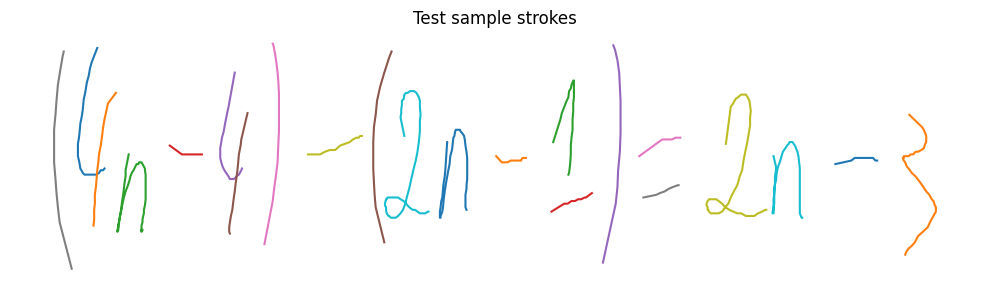

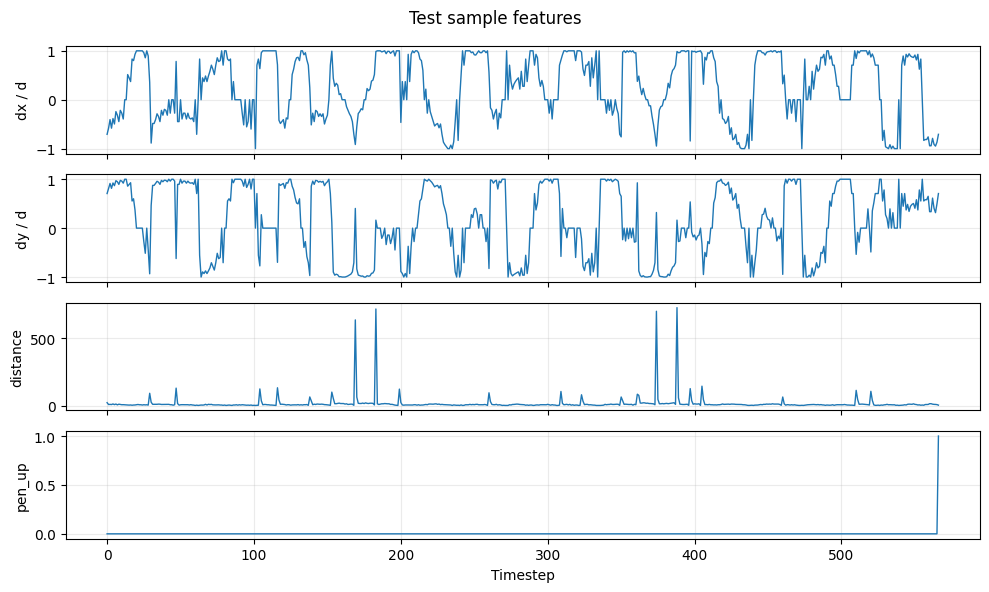

In [ ]:
# Inference probe on one sample with static visualizations.
train_model.eval()
infer_dataset = InkmlDataset(TEST_ANNOTATION, INKML_ROOT, loaded_vocab)
feature, target, input_len, target_len = infer_dataset[0]

with torch.no_grad():
    emission = train_model(feature.unsqueeze(0).to(device))[0, :input_len].cpu()

pred_tokens = decoder(emission)
target_tokens = loaded_vocab.decode(target[:target_len].tolist())

print("Prediction:", " ".join(pred_tokens))
print("Target:    ", " ".join(target_tokens))
print("Edit distance:", edit_distance(pred_tokens, target_tokens))

sample_path = infer_dataset.samples[0][0]
sample_ink = Inkml(INKML_ROOT / sample_path)
fig_ink = plot_inkml(sample_ink, title="Test sample strokes")
fig_features = plot_feature_channels(feature, title="Test sample features")
plt.show()


In [ ]:
plot_prediction_probs(emission, loaded_vocab, title="Model emission probabilities")

## Task 10: Retrain from a checkpoint and save best wer models

In [ ]:
def fit_with_early_stopping_wer(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.CTCLoss,
    decoder: GreedyCTCDecoder,
    vocab: Vocab,
    device: torch.device,
    config: dict,
    run=None,
    checkpoint_dir: str | Path | None = None,
) -> tuple[list[dict[str, float]], Path | None]:
    """Train manually with WandB logging, checkpointing, and early stopping."""
    # TODO: load checkpoint
    # TODO: rewrite the training loop to save best wer models instead of best loss models
    checkpoint_dir = Path(checkpoint_dir) if checkpoint_dir is not None else Path("checkpoints")
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    best_wer = float("inf")
    best_checkpoint_path: Path | None = None
    patience_counter = 0
    history: list[dict[str, float]] = []

    epoch_bar = progress_epochs(config["num_epochs"])
    for epoch in epoch_bar:
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            max_batches=config["max_train_batches"],
            grad_clip_norm=config["grad_clip_norm"],
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            decoder,
            vocab,
            device,
            max_batches=config["max_val_batches"],
        )
        val_loss = val_metrics["loss"]
        val_wer = val_metrics["wer"]
        val_empty_pred_rate = val_metrics["empty_pred_rate"]

        if run is not None:
            run.log(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_wer": val_wer,
                    "val_empty_pred_rate": val_empty_pred_rate,
                    "epoch": epoch,
                }
            )

        log_progress(
            epoch_bar,
            train_loss=train_loss,
            val_loss=val_loss,
            val_wer=val_wer,
            empty=val_empty_pred_rate,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_wer": val_wer,
                "val_empty_pred_rate": val_empty_pred_rate,
            }
        )

        if val_wer < best_wer - config["min_delta"]:
            best_wer = val_wer
            patience_counter = 0
            best_checkpoint_path = checkpoint_dir / f"best_model_epoch{epoch}.pt"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                    "val_wer": val_wer,
                    "config": config,
                },
                best_checkpoint_path,
            )
        else:
            patience_counter += 1
            if patience_counter >= config["patience"]:
                break

    return history, best_checkpoint_path


## Bonus Tasks

These are optional and can improve your final score or leaderboard standing.

1. Symbol/relation WER: log separate `wer_sym` and `wer_rel` by filtering relation tokens `Above`, `Below`, `Inside`, `NoRel`, `Right`, `Sub`, `Sup`.
2. Relation-constraint loss: penalize relation probability on pen-down timesteps:

$$
L_{constraint} = -\log\left(1 - \sum_t p_{rel,t} \cdot pen\_down_t + \epsilon \right)
$$

and combine it with CTC:

$$
L = L_{CTC} + \lambda L_{constraint}
$$

3. Try a beam-search decoder for inference.
4. Improve the visual inspectors, for example by annotating decoded tokens along the timestep axis.


## Grading Rubric

- Vocab + dataset: 20%
- Feature extraction + collate: 20%
- Model + CTC training loop: 25%
- Inference + decoder: 15%
- Metrics: 10%
- Reproducibility and WandB logs: 10%

Performance is used for comparison or bonus, not as a hard release-blocking threshold.


## Autograder Contract Smoke Test

Do not edit this section. It checks the canonical API surface only. The hidden autograder will run additional tests against these same names.


In [ ]:
import plotly.graph_objects as go

epochs:   0%|          | 0/1 [00:00<?, ?it/s]

smoke:   0%|          | 0/1 [00:00<?, ?it/s]

train:   0%|          | 0/1 [00:00<?, ?it/s]

eval:   0%|          | 0/1 [00:00<?, ?it/s]

Autograder contract smoke test passed.


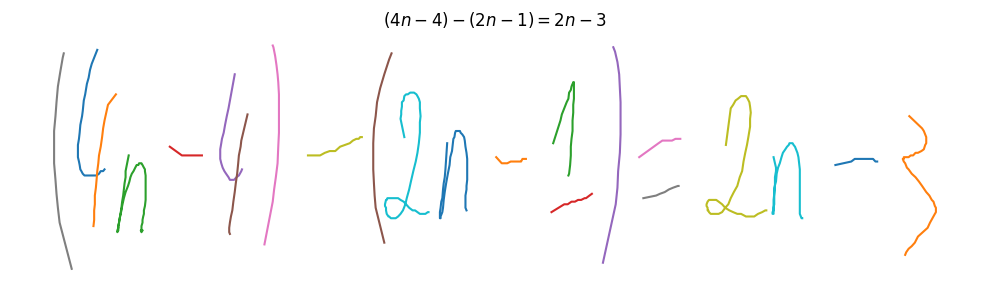

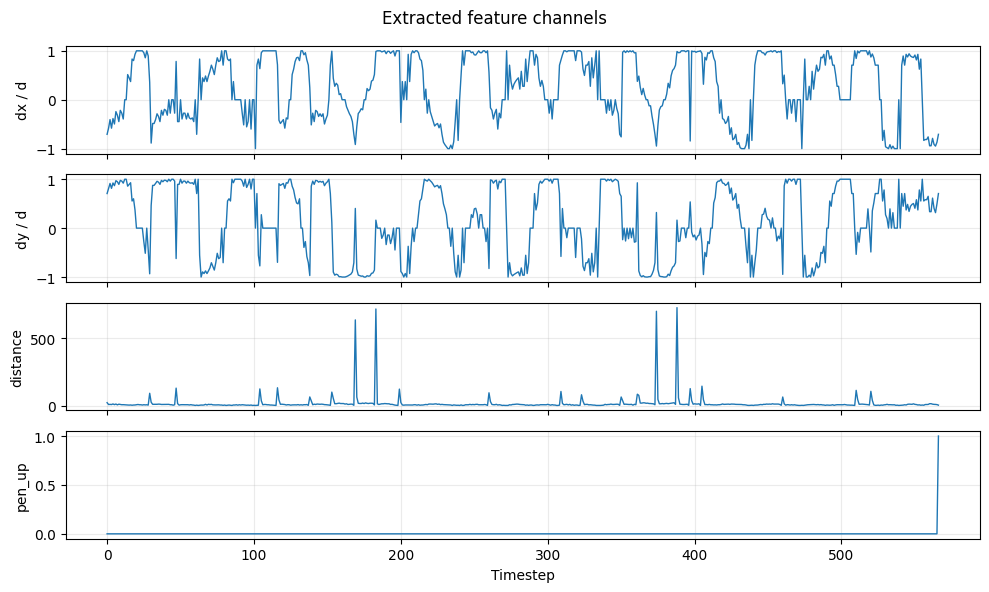

In [ ]:
# DO NOT EDIT: canonical API smoke test
required_symbols = [
    "get_unique_tokens",
    "Vocab",
    "Segment",
    "Inkml",
    "feature_extraction",
    "plot_inkml",
    "plot_feature_channels",
    "plot_prediction_probs",
    "InkmlDataset",
    "collate_fn",
    "create_dataloaders",
    "LSTMTemporalClassifier",
    "GreedyCTCDecoder",
    "edit_distance",
    "word_error_rate",
    "compute_ctc_loss",
    "decode_batch",
    "train_one_epoch",
    "evaluate_model",
    "fit_with_early_stopping",
    "progress_batches",
    "progress_epochs",
    "log_progress",
]
for name in required_symbols:
    assert name in globals(), f"Missing required symbol: {name}"

# Progress helper contract
progress_bar = progress_epochs(1)
log_progress(progress_bar, smoke=1.0)
progress_bar.close()
assert list(progress_batches(["batch"], "smoke", max_batches=1))[0][1] == "batch"

# Vocab contract
contract_vocab = Vocab(VOCAB_PATH)
assert contract_vocab.char2idx[""] == 0
assert contract_vocab.encode(r"- Right \sqrt Inside 2".split()) == [5, 37, 74, 30, 10]

# Dataset/collate/dataloader contract
contract_ds = InkmlDataset(TEST_ANNOTATION, INKML_ROOT, contract_vocab)
contract_item = contract_ds[0]
assert len(contract_item) == 4
contract_batch = collate_fn([contract_ds[0], contract_ds[1]])
assert contract_batch[0].shape[0] == 2 and contract_batch[0].shape[-1] == 4
assert contract_batch[2].dtype == torch.long and contract_batch[3].dtype == torch.long
contract_train_loader, contract_val_loader, contract_test_loader = create_dataloaders(
    TRAIN_ANNOTATION,
    VAL_ANNOTATION,
    TEST_ANNOTATION,
    INKML_ROOT,
    contract_vocab,
    batch_size=2,
    num_workers=0,
)
assert isinstance(contract_train_loader, DataLoader)
assert isinstance(next(iter(contract_train_loader)), tuple)

# Model/decoder/metric contract
contract_model = LSTMTemporalClassifier(num_classes=len(contract_vocab.char2idx), hidden_size=8, num_layers=1)
contract_out = contract_model(torch.randn(2, 10, 4))
assert contract_out.shape == (2, 10, len(contract_vocab.char2idx))
assert torch.allclose(contract_out.exp().sum(dim=-1), torch.ones(2, 10), atol=1e-5)

contract_decoder = GreedyCTCDecoder(contract_vocab)
decoded = contract_decoder(contract_out[0])
assert isinstance(decoded, list)
assert isinstance(edit_distance(["a"], ["a", "b"]), int)
assert isinstance(word_error_rate([["a"]], [["a", "b"]]), float)

# Manual CTC/training contract
small_vocab = Vocab()
small_vocab.char2idx = {"": 0, "a": 1, "b": 2}
small_vocab._refresh_inverse()
small_model = LSTMTemporalClassifier(num_classes=3, hidden_size=8, num_layers=1)
small_criterion = nn.CTCLoss(blank=0, zero_infinity=True)
small_optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)
small_batch = (
    torch.randn(2, 12, 4),
    torch.tensor([[1, 2], [1, 0]], dtype=torch.long),
    torch.tensor([12, 12], dtype=torch.long),
    torch.tensor([2, 1], dtype=torch.long),
)
small_loss, small_out = compute_ctc_loss(small_model, small_criterion, small_batch, torch.device("cpu"))
assert torch.is_tensor(small_loss) and torch.isfinite(small_loss)
small_train_loss = train_one_epoch(small_model, [small_batch], small_optimizer, small_criterion, torch.device("cpu"))
small_metrics = evaluate_model(small_model, [small_batch], small_criterion, GreedyCTCDecoder(small_vocab), small_vocab, torch.device("cpu"))
assert math.isfinite(small_train_loss)
assert set(small_metrics) >= {"loss", "wer"}

# Visualization contract
contract_ink = Inkml(INKML_ROOT / contract_ds.samples[0][0])
fig1 = plot_inkml(contract_ink)
fig2 = plot_feature_channels(contract_item[0])
fig3 = plot_prediction_probs(contract_out[0], contract_vocab)
assert isinstance(fig1, plt.Figure)
assert isinstance(fig2, plt.Figure)
assert isinstance(fig3, go.Figure)

print("Autograder contract smoke test passed.")
